In [1]:
import pandas as pd
import numpy as np
import os
import re
from copy import deepcopy 

from collections import Counter
import seaborn as sns
import matplotlib.pyplot as plt

In [77]:
base_dir = 'data/english_only/prompting_results_clean/with_metrics/' #experiment 1
#base_dir = 'data/english_only/100k_results/with_metrics' #experiment 2

In [3]:
from aggregate_metrics_helper import *

In [4]:
os.chdir('/shared/0/projects/research-jam-summer-2024/')
pd.options.mode.copy_on_write = True

In [79]:
os.listdir('data/english_only/100k_results/')

['100k_results_raw',
 'wildchat_subset_en_100k_Mistral-Large-Instruct.jsonl',
 'with_metrics',
 'wildchat_subset_en_100k_Mixtral-8x7B.jsonl',
 'wildchat_subset_en_100k_Llama-3.1-70B.jsonl']

In [5]:
for f in os.listdir(base_dir):
    if f.startswith('wildchat_subset_en_2k_prompting') and not f.endswith('_end.jsonl') and not f.endswith('_embeddings.npz') and not f.endswith('lexical.jsonl') and not f.endswith('MERGED.jsonl') and not f.endswith('_POS_DEP.jsonl'):
        print(f)

wildchat_subset_en_2k_prompting_Qwen2-72B-Instruct.jsonl
wildchat_subset_en_2k_prompting_c4ai-command-r-v01.jsonl
wildchat_subset_en_2k_prompting_Mixtral-8x7B-Instruct-v0.1.jsonl
wildchat_subset_en_2k_prompting_Meta-Llama-3-70B-Instruct.jsonl
wildchat_subset_en_2k_prompting_Mistral-Large-Instruct.jsonl
wildchat_subset_en_2k_prompting_Phi-3-medium-4k-instruct.jsonl
wildchat_subset_en_2k_prompting_Mistral-7B-Instruct-v0.3.jsonl
wildchat_subset_en_2k_prompting_Meta-Llama-3.1-8B-Instruct.jsonl
wildchat_subset_en_2k_prompting_Meta-Llama-3.1-70B-Instruct.jsonl


In [13]:
metrics = pd.concat([make_human_vs_llm_df(f, base_dir) for f in os.listdir(base_dir)[:2]
                       if f.startswith('wildchat_subset_en_2k_prompting') and 
                       not f.endswith('_end.jsonl') and not f.endswith('_embeddings.npz') and 
                       not f.endswith('lexical.jsonl') and not f.endswith('MERGED.jsonl') and 
                       not f.endswith('_POS_DEP.jsonl')]).reset_index(drop=True)

wildchat_subset_en_2k_prompting_Qwen2-72B-Instruct.jsonl
read metrics
read dependency parse metrics
read embeddings


In [14]:
print(metrics.shape)
print()
metrics.head()

(31815, 44)



,hashed_ip,model,conversation_hash,prompt,human_perplexity,llm_perplexity,human_subjectivity,llm_subjectivity,human_liwc,human_politeness,...,human_dep_dpth,human_dep_brth,human_dep_dep_dist,llm_dep_dpth,llm_dep_brth,llm_dep_dep_dist,human_sbert,llm_sbert,human_luar,llm_luar
0,568ecf3349b46c238268f63bcdbb2e12cd88feea3052b9...,wildchat_subset_en_2k_prompting_Qwen2-72B-Inst...,231dc924f9bf607871bf3e5699930833,Prompt_1,158.865589,42.382804,6.000000e-01,5.500000e-01,"{'achieve': 0.0, 'affect': 0.0, 'anger': 0.0, ...",0.120022,...,2,5,2.222222,4,5,1.296296,"[0.058730680495500565, -0.027935944497585297, ...","[0.01683928444981575, 0.11676625162363052, -0....","[0.13018760085105896, 0.248081773519516, -0.19...","[-0.2808733284473419, -0.851929247379303, 0.34..."
1,d3c81b62172c8e48ca874e118ee957e3db84d1f9b4d5b1...,wildchat_subset_en_2k_prompting_Qwen2-72B-Inst...,edf58f8e33a00f9c374d448aad703650,Prompt_1,26.437630,17.138431,1.000000e-10,7.250000e-01,"{'achieve': 0.0, 'affect': 0.0, 'anger': 0.0, ...",0.984959,...,4,3,1.375000,8,6,1.415584,"[0.016433479264378548, -0.010125488974153996, ...","[-0.007542246486991644, -0.08430641144514084, ...","[-0.3781570494174957, -0.3390761911869049, 0.3...","[0.6965972185134888, -0.194828599691391, -0.06..."
2,6e9b81c31754d99e4f9df95bd6317c844f444f4eedd216...,wildchat_subset_en_2k_prompting_Qwen2-72B-Inst...,544d60f14b495ca7e7ae9dbe2ed63220,Prompt_1,64.936443,42.698814,7.272727e-01,6.250000e-01,"{'achieve': 0.0, 'affect': 0.0, 'anger': 0.0, ...",0.607415,...,7,4,1.516129,6,5,1.521739,"[-0.04167027771472931, -0.03375384956598282, 0...","[0.00025410144007764757, 0.0863824188709259, 0...","[0.21861684322357178, 0.04622489586472511, -0....","[-0.2201990783214569, -0.31897538900375366, -0..."
3,5ed67e4bf7e0054269cd7281f76a05f7fa75bf36856ea7...,wildchat_subset_en_2k_prompting_Qwen2-72B-Inst...,1f63b7d1807287f1d1ecfb8710075789,Prompt_1,45.380340,58.248050,5.000000e-01,5.400000e-01,"{'achieve': 0.0, 'affect': 0.0487804878, 'ange...",0.751625,...,7,10,2.643836,4,8,1.872340,"[-0.04662158340215683, 0.0035614471416920424, ...","[-0.06962382048368454, -0.0201204102486372, -0...","[-0.02591072767972946, -0.02138587459921837, -...","[0.5467545986175537, 0.12464392185211182, -0.5..."
4,c29121a61bae1319376607d7a8475b8a7339ee288fa66c...,wildchat_subset_en_2k_prompting_Qwen2-72B-Inst...,245490794224427cf7c4be8fdba35f8c,Prompt_1,6.070055,14.332415,5.187500e-01,1.000000e-10,"{'achieve': 0.0461538462, 'affect': 0.15384615...",0.480610,...,10,18,3.044321,4,6,1.573333,"[0.03154560178518295, -0.023224515840411186, -...","[-0.01936245523393154, 0.04322631657123566, 0....","[0.6277977228164673, 0.3861098885536194, -0.49...","[0.0921144187450409, 0.22655180096626282, 0.09..."


In [15]:
# check that columns are exactly the merge keys and human/llm metrics from all_metrics 

print(Counter(['human_'+k in metrics.columns for k in all_metrics]))
print(Counter(['llm_'+k in metrics.columns for k in all_metrics]))
print(Counter([k in metrics.columns for k in merge_keys]))
print(Counter([k in merge_keys or re.sub('human_|llm_','',k) in all_metrics 
               for k in metrics.columns]))


Counter({True: 20})
Counter({True: 20})
Counter({True: 4})
Counter({True: 44})


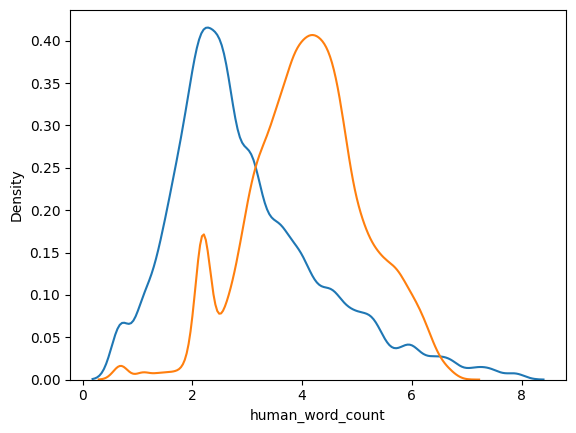

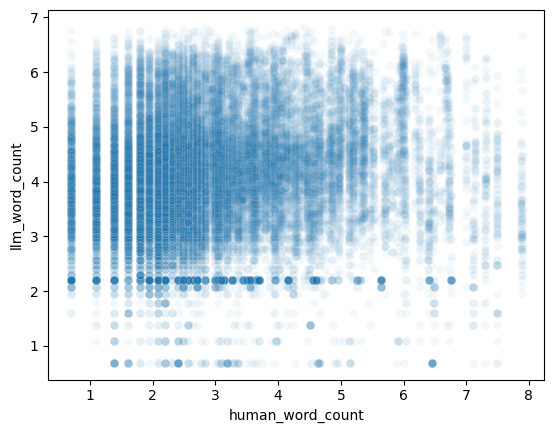

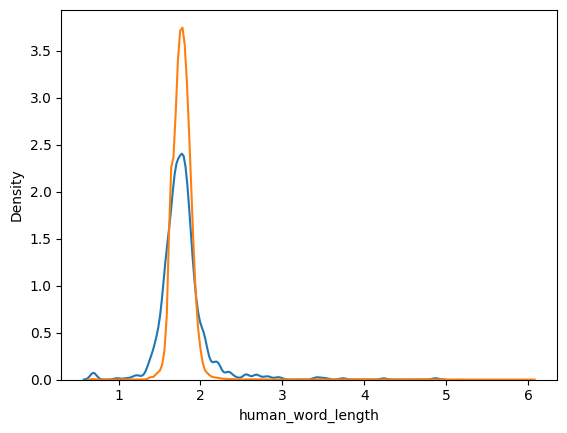

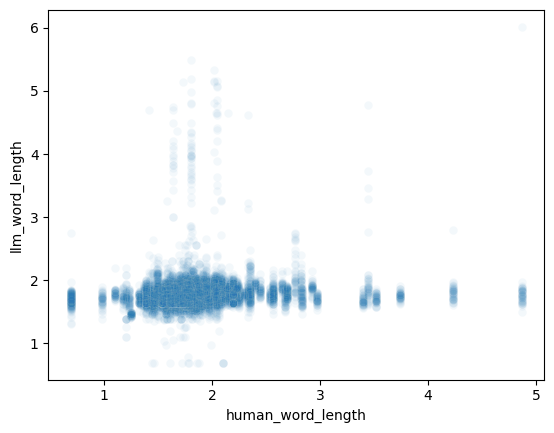

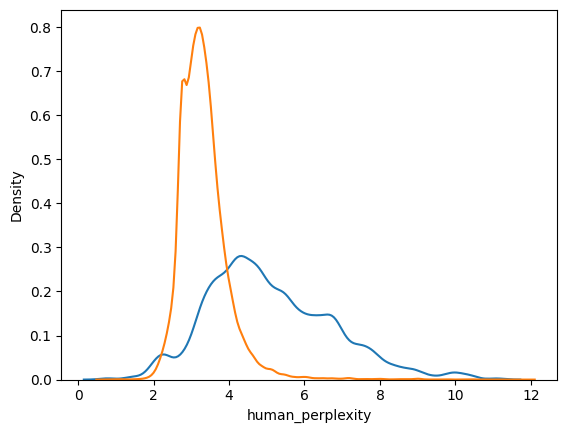

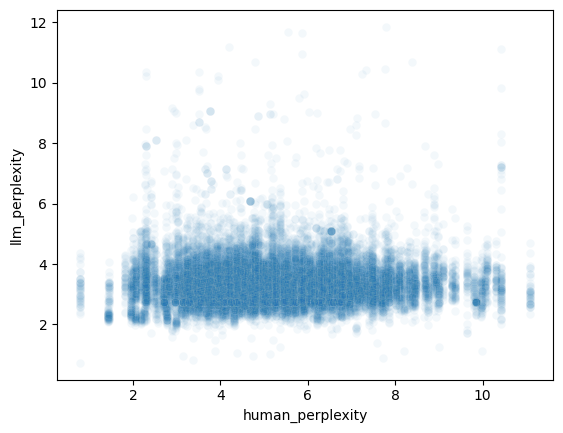

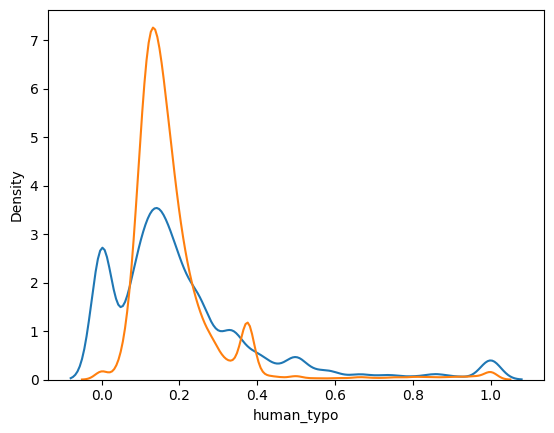

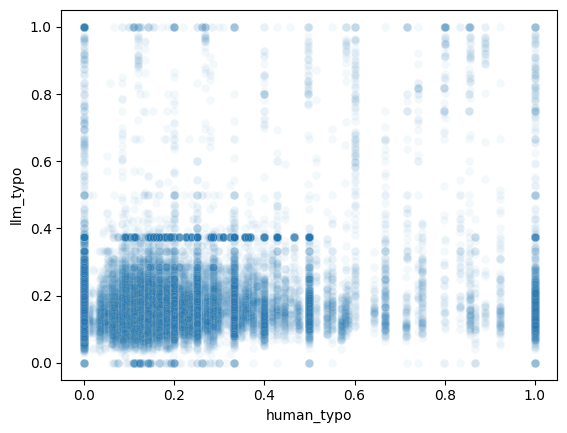

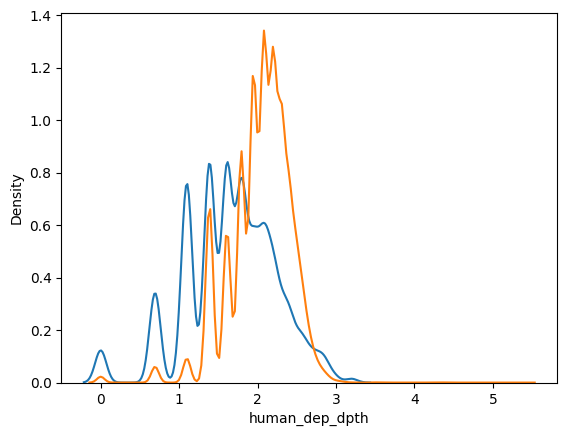

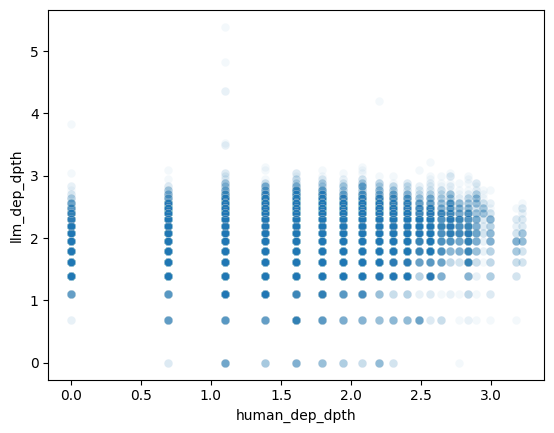

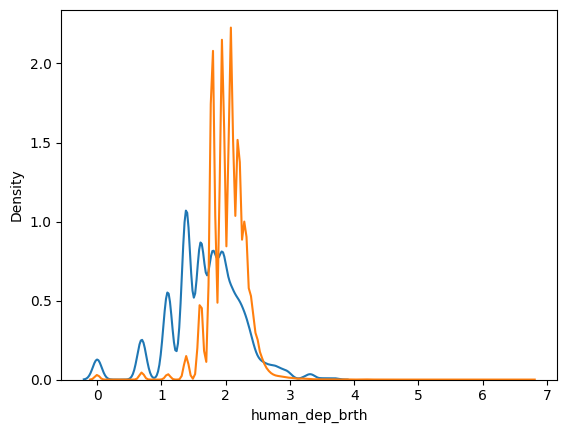

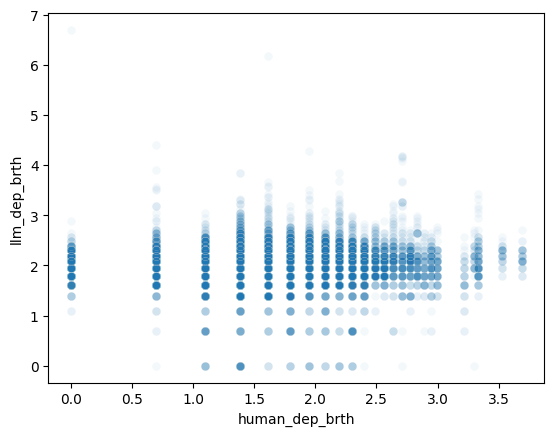

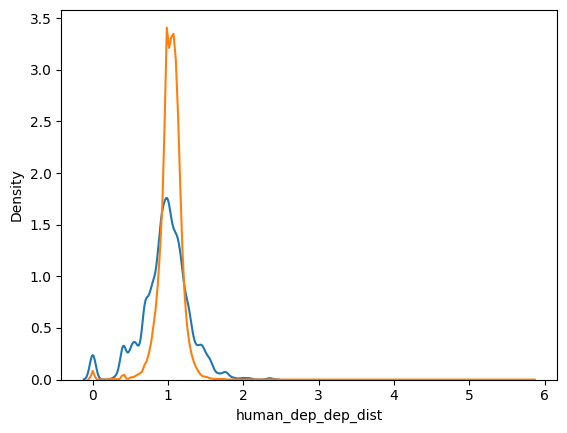

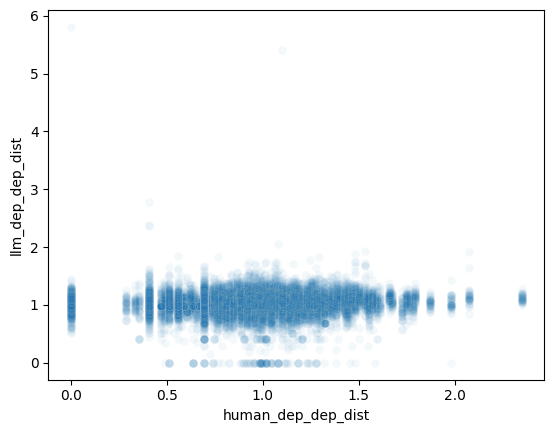

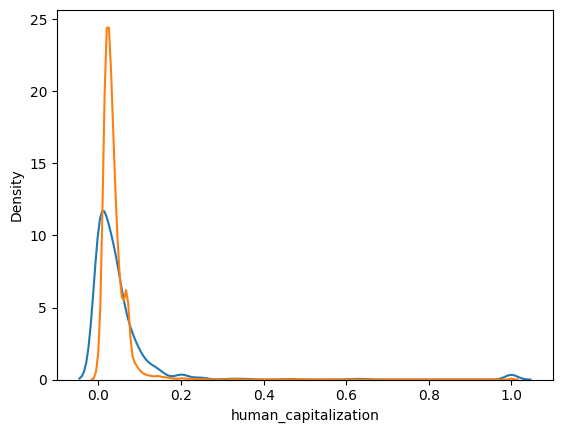

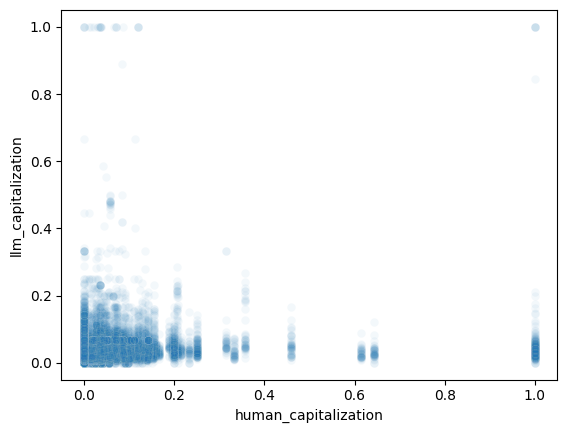

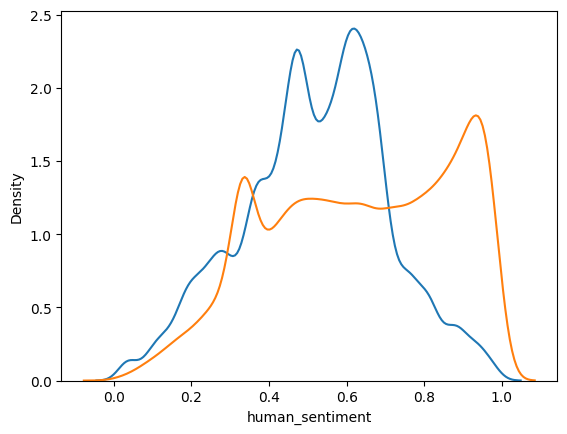

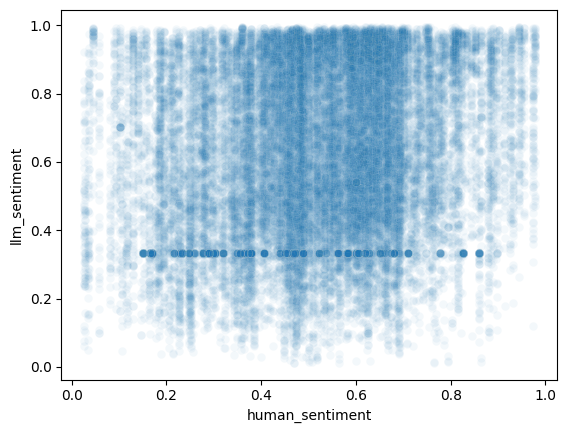

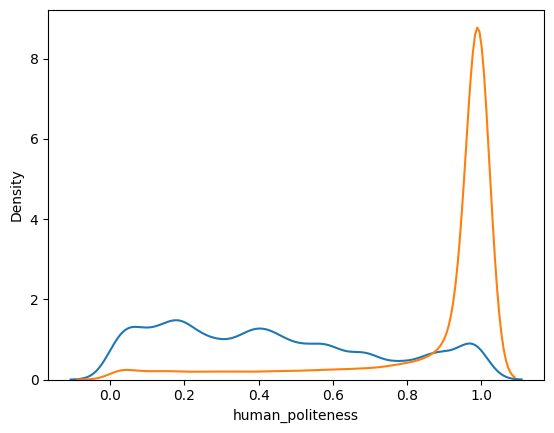

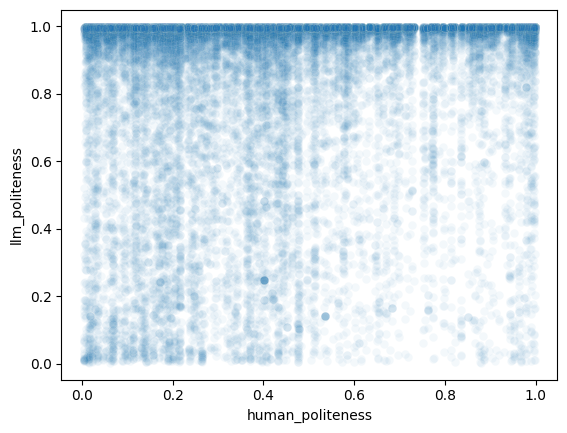

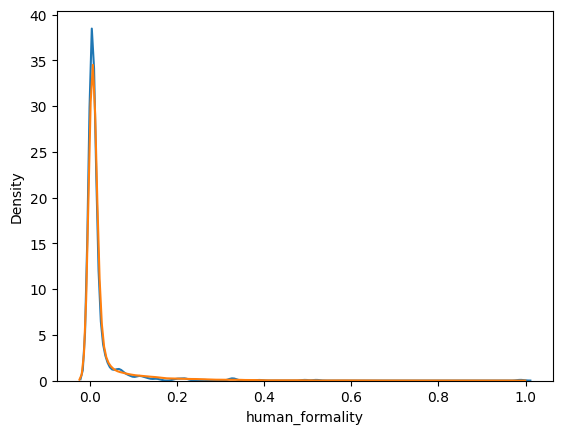

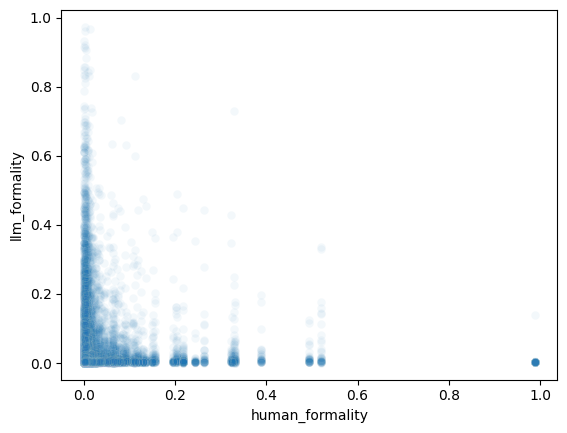

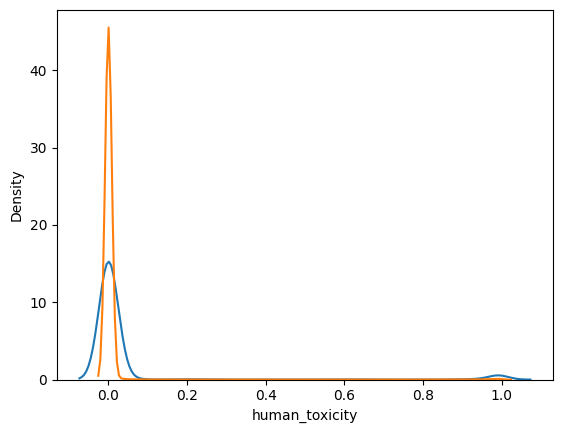

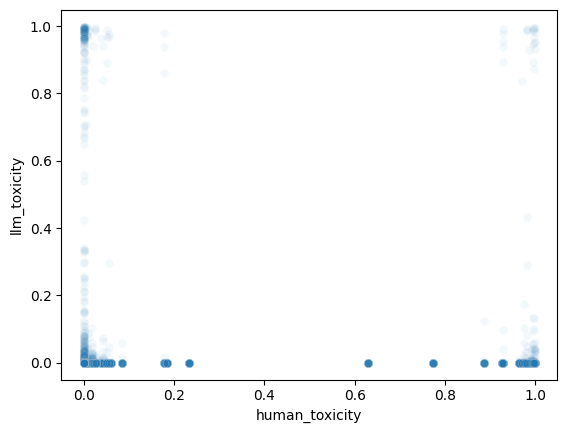

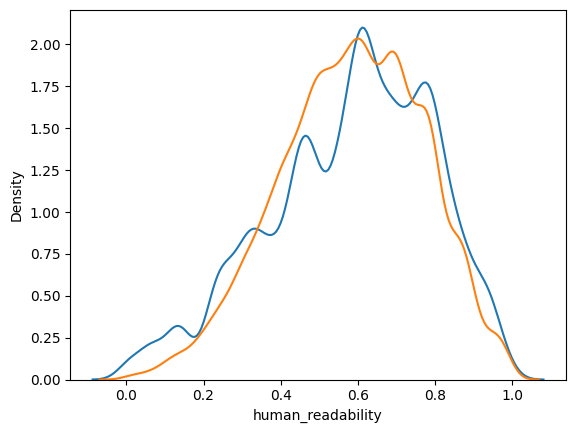

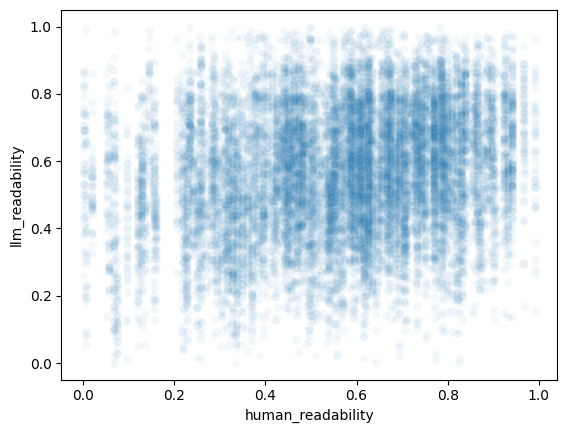

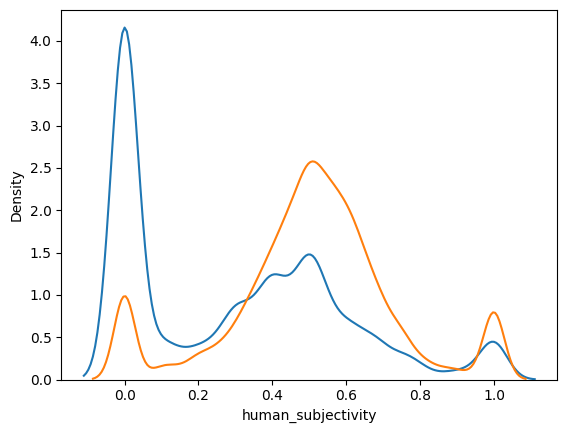

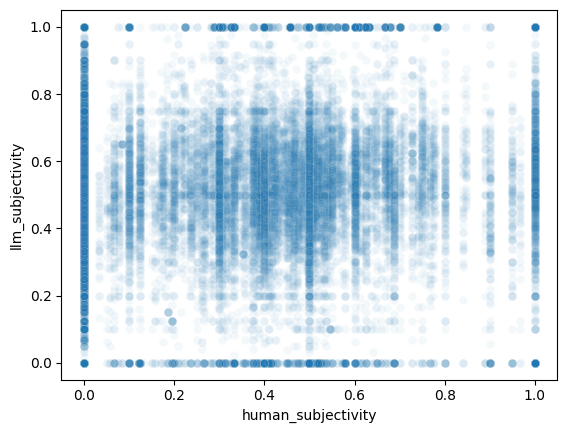

In [49]:
# plot and log transform
for k in all_metrics:
    if all_metrics[k] == 'scalar':
        sns.kdeplot(metrics['human_'+k])
        sns.kdeplot(metrics['llm_'+k])
        plt.show()
        sns.scatterplot(x = metrics['human_'+k], y = metrics['llm_'+k], alpha=0.05)
        plt.show()


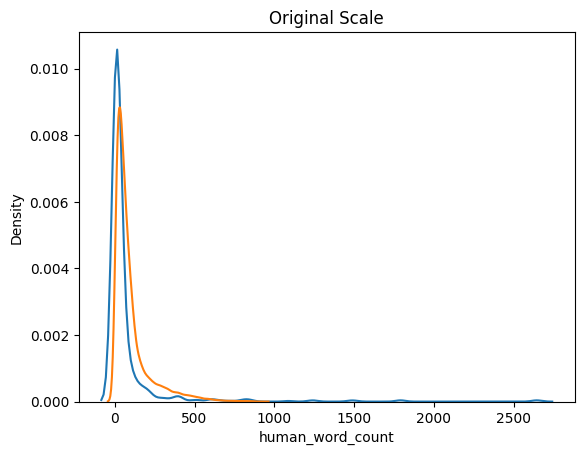

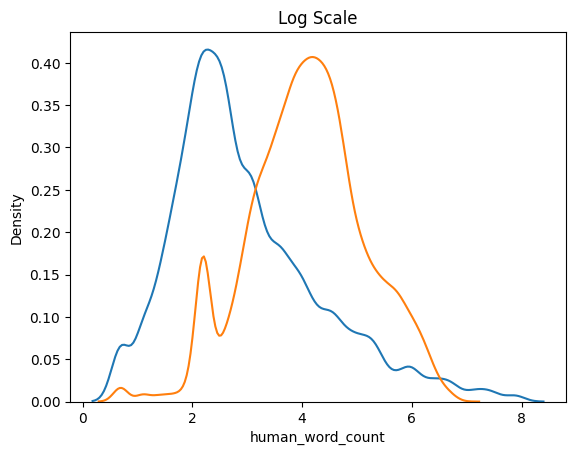

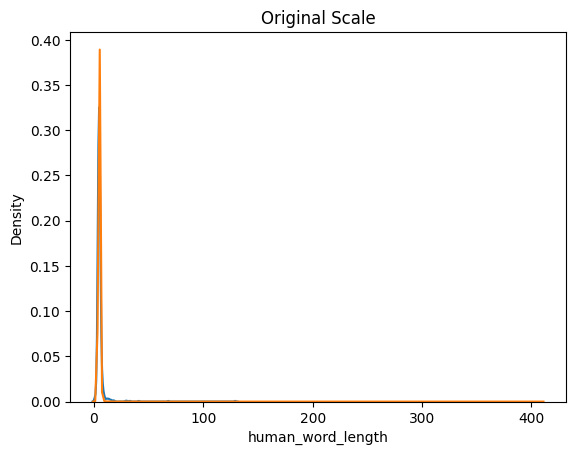

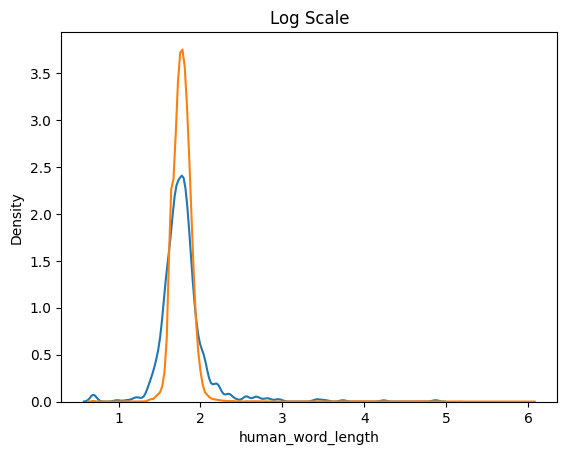

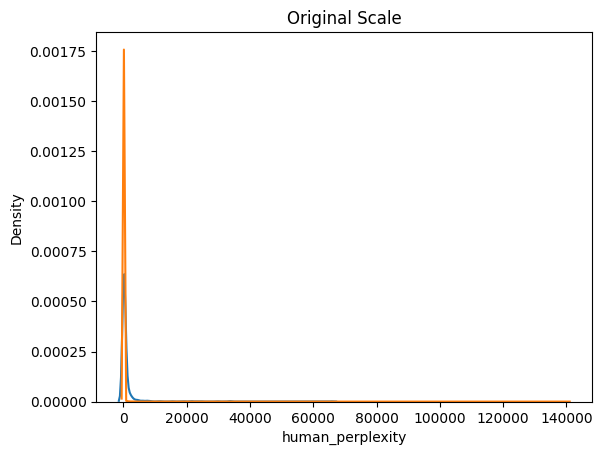

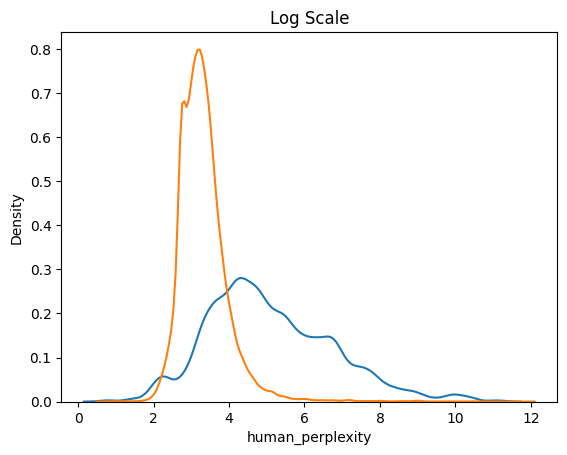

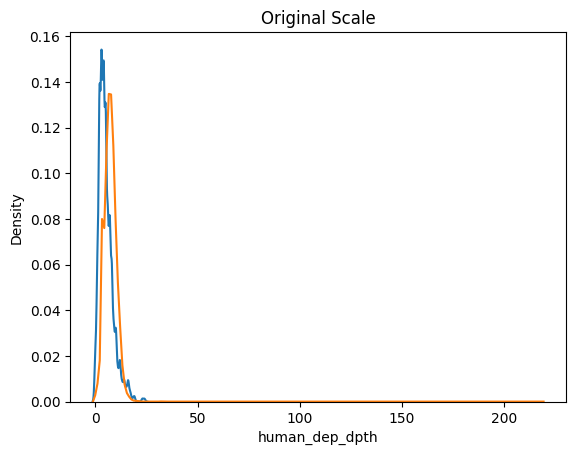

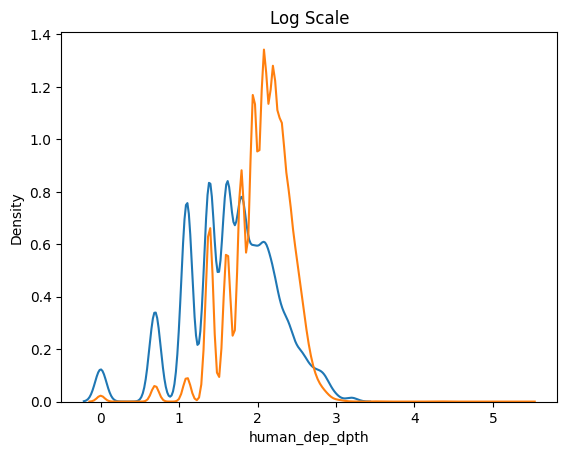

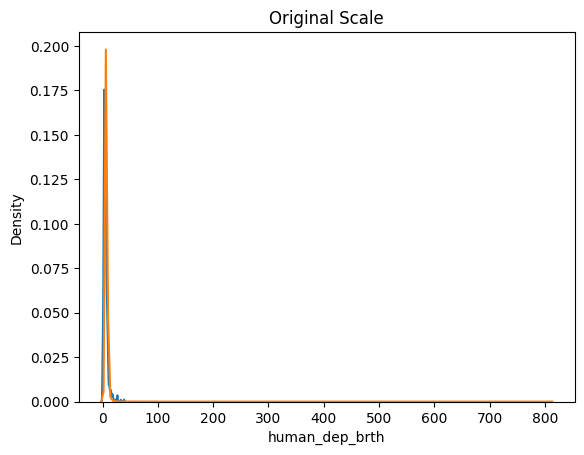

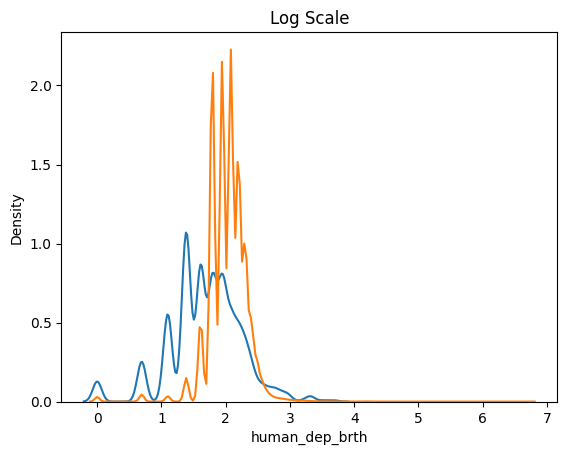

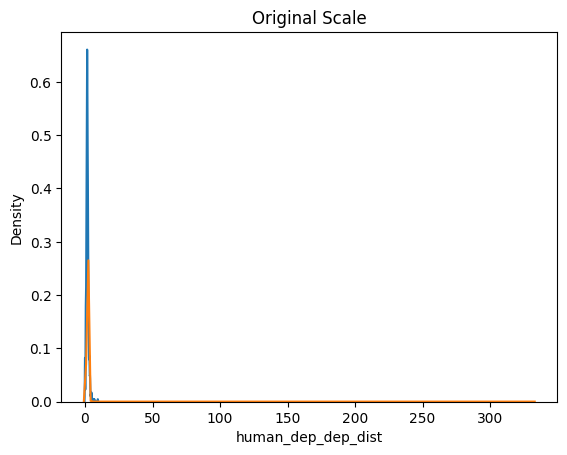

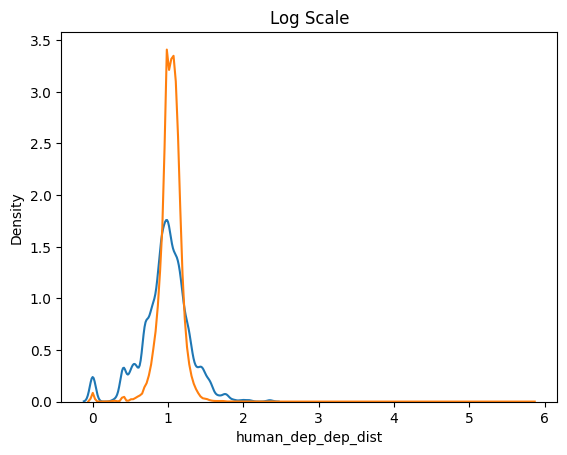

In [17]:
for k in ['word_count', 'word_length', 'perplexity', 'dep_dpth', 'dep_brth', 'dep_dep_dist']:
    if all_metrics[k] == 'scalar':
        sns.kdeplot(metrics['human_'+k])
        sns.kdeplot(metrics['llm_'+k])
        plt.title('Original Scale')
        plt.show()

        sns.kdeplot(np.log(metrics['human_'+k]+1))
        sns.kdeplot(np.log(metrics['llm_'+k]+1))
        plt.title('Log Scale')
        plt.show()


In [18]:
# log scale heavy-tailed count metrics
for k in ['word_count', 'word_length', 'perplexity', 'dep_dpth', 'dep_brth', 'dep_dep_dist']:
    metrics['human_'+k] = np.log(metrics['human_'+k]+1)
    metrics['llm_'+k] = np.log(metrics['llm_'+k]+1)

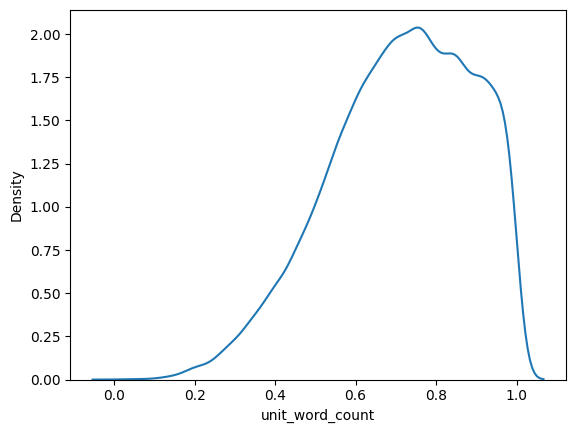

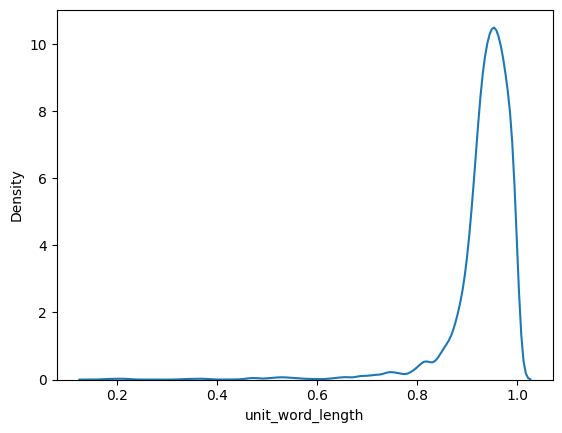

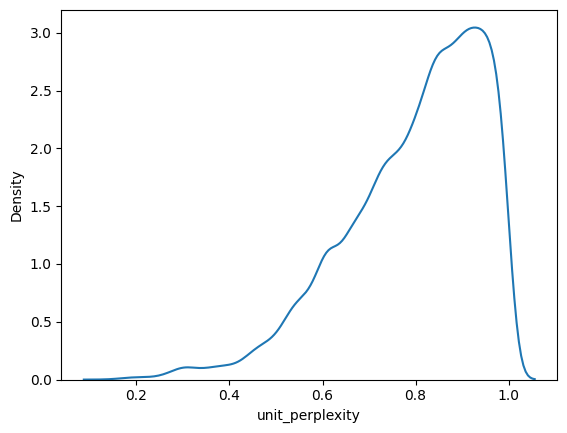

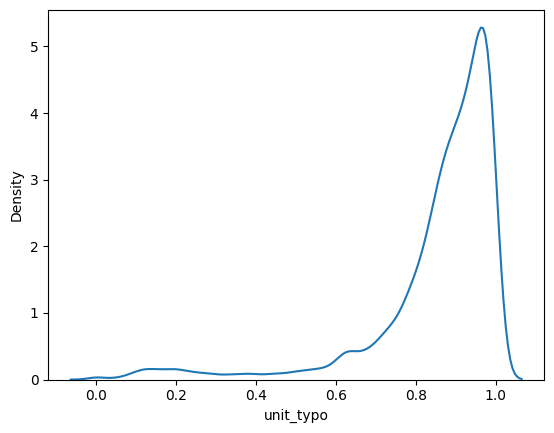

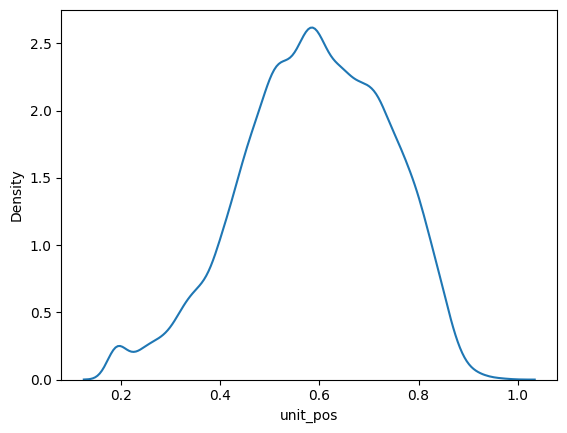

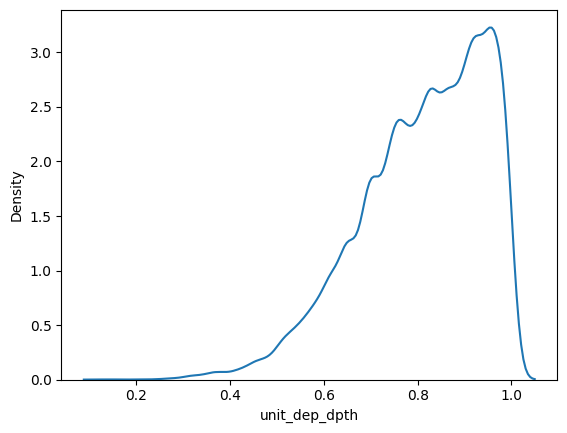

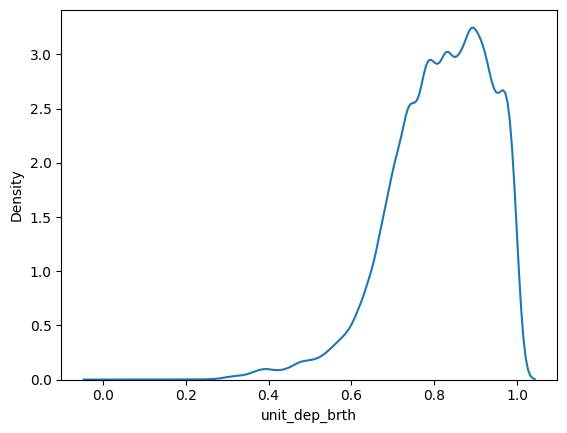

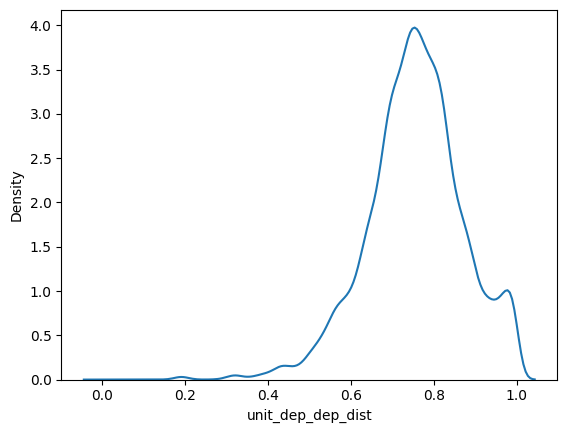

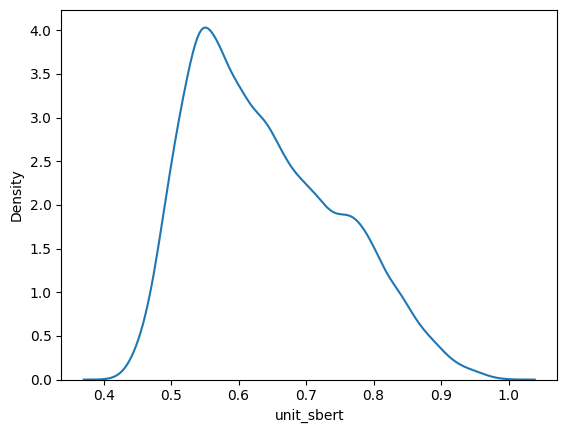

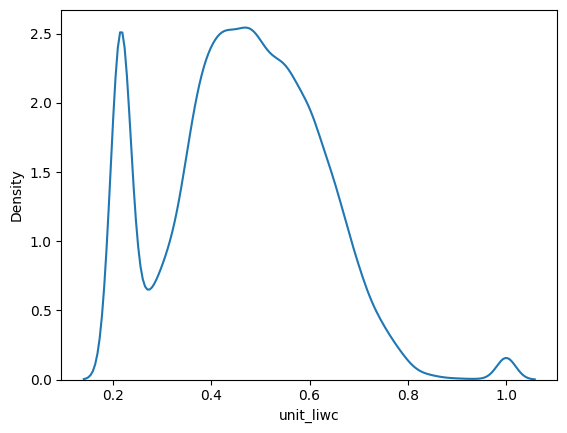

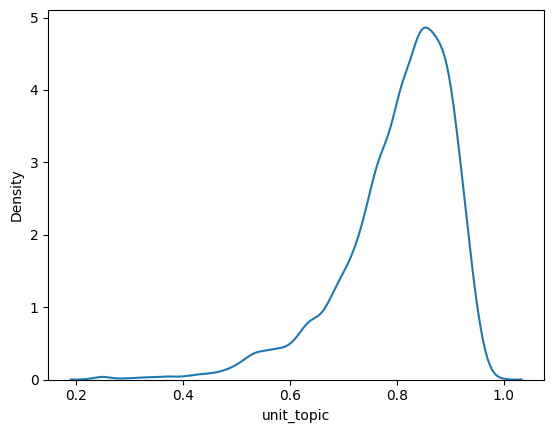

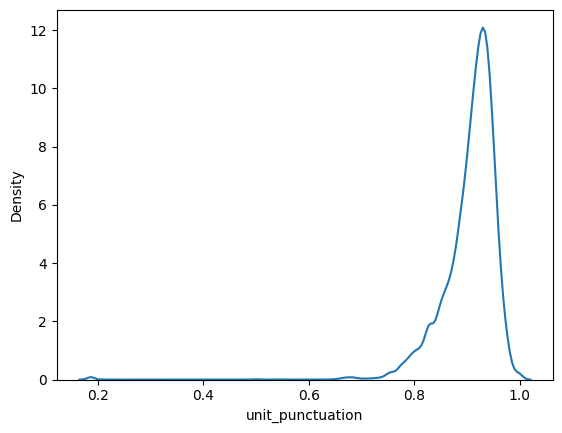

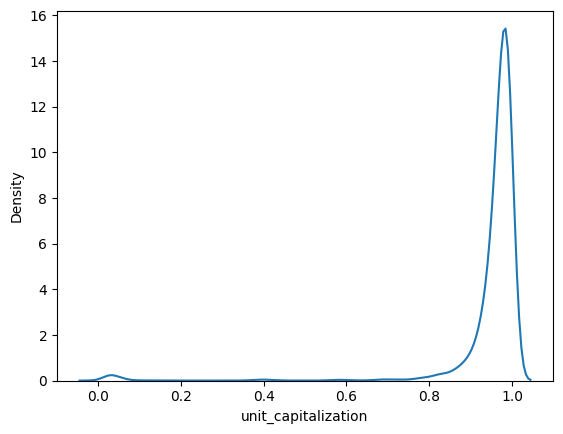

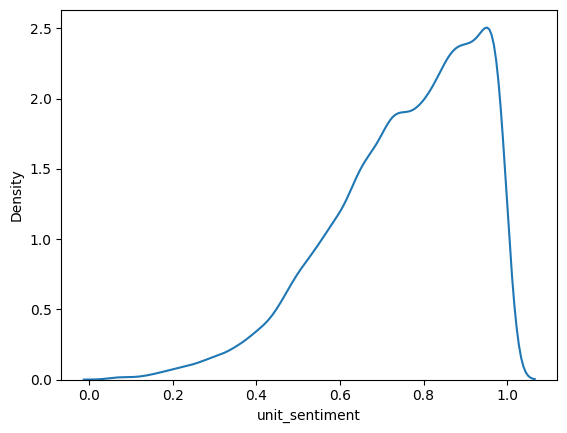

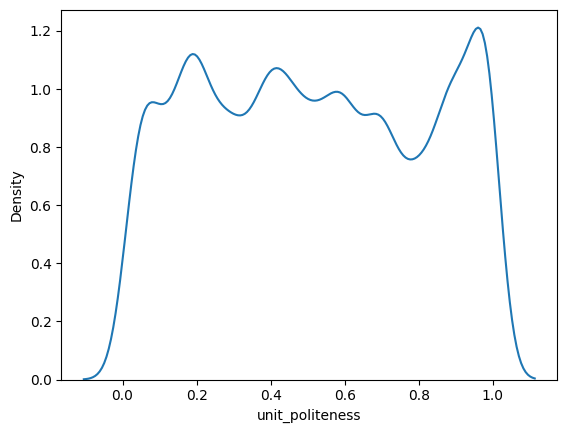

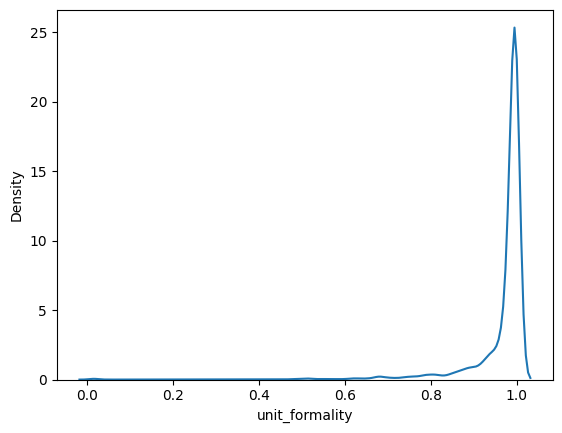

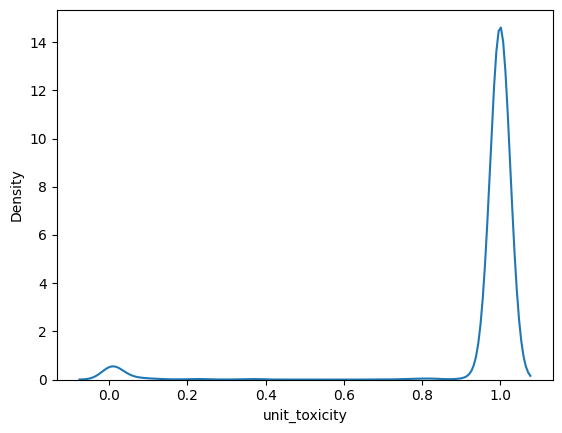

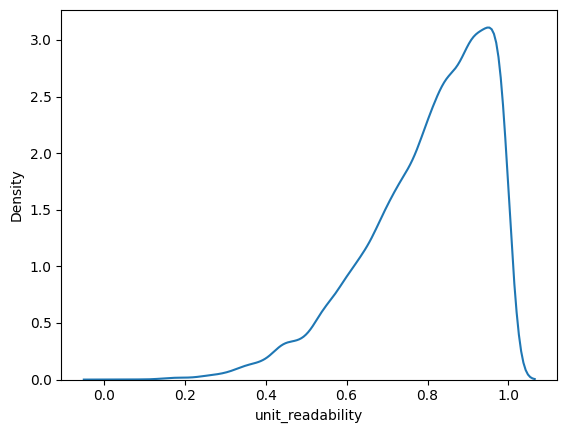

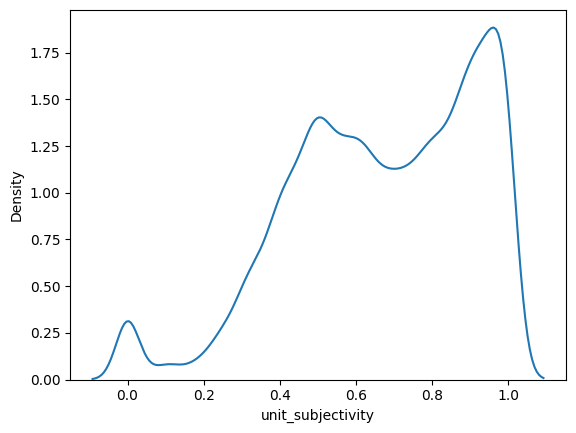

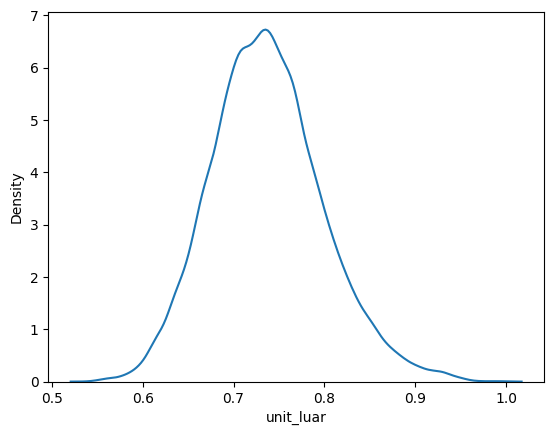

In [19]:
# CREATE NORMALIZED SIMILARITIES IN [0,1]
df_unit = metrics[merge_keys]
for k in all_metrics:
    df_unit.loc[:,'unit_'+k] = diff_unit(metrics['human_'+k], metrics['llm_'+k], all_metrics[k], 
                                         rescale = k in ['word_count', 'word_length', 'perplexity', 
                                                         'dep_dpth', 'dep_brth', 'dep_dep_dist'])
    sns.kdeplot(df_unit['unit_'+k])
    plt.show()

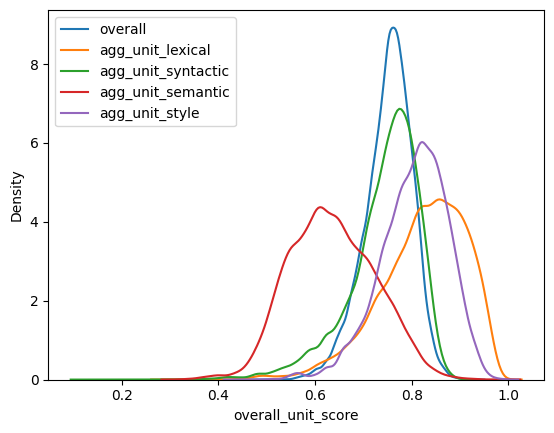

In [20]:
# AGGREGATED SCORES VIA UNIT NORMALIZATION
df_unit = aggregate_scores(df_unit, method = 'unit')

In [25]:
df_unit.to_csv('data/agg_metrics/unit_normed_metrics.csv', index=None)

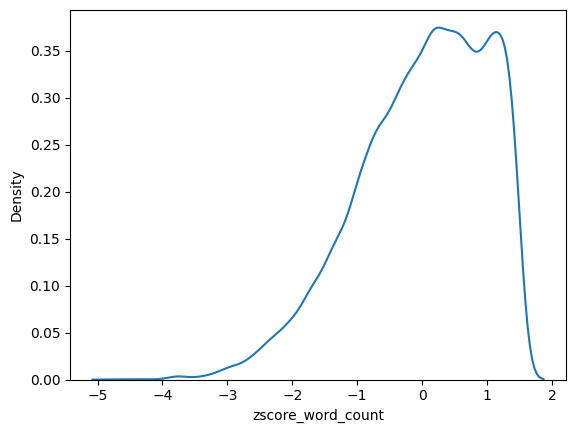

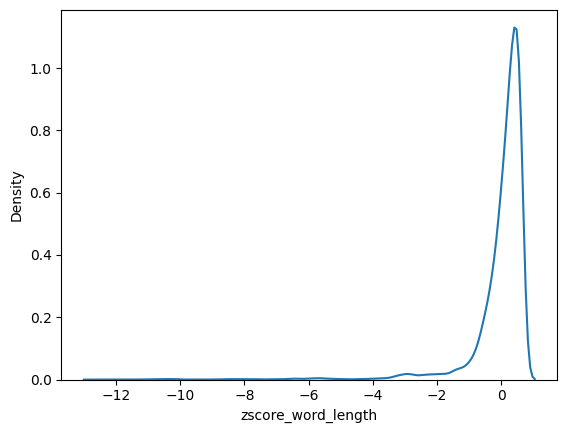

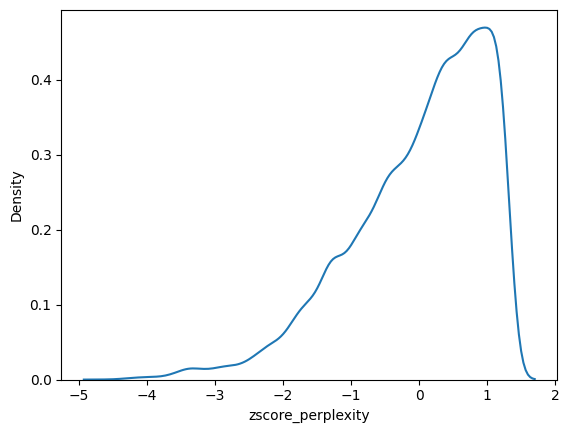

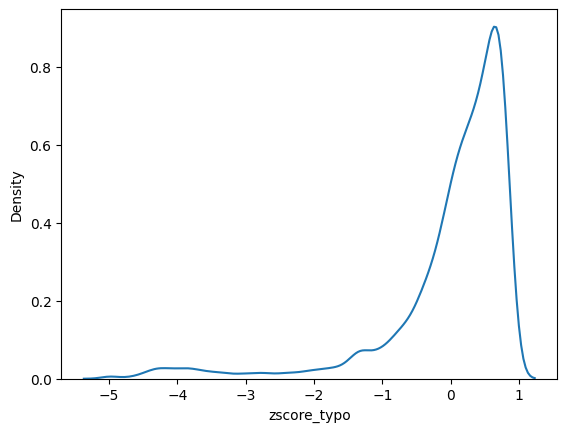

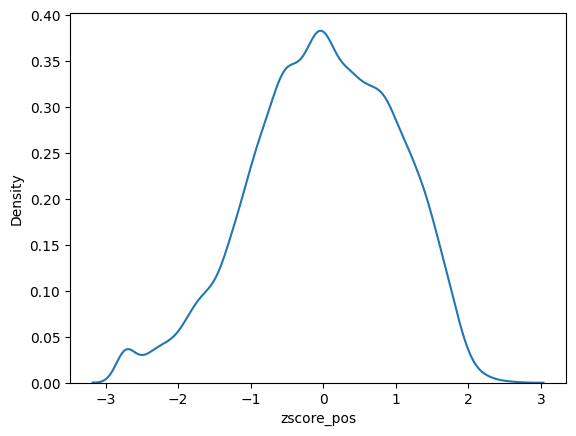

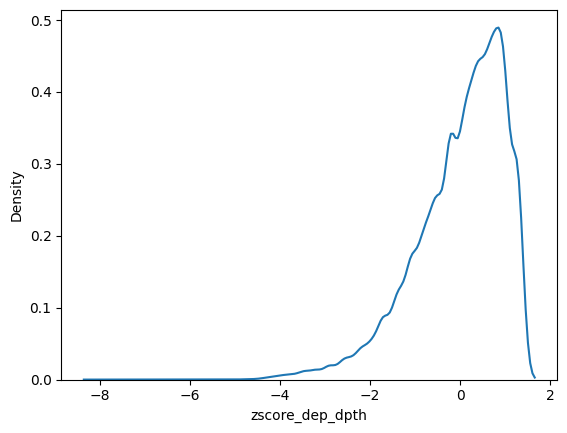

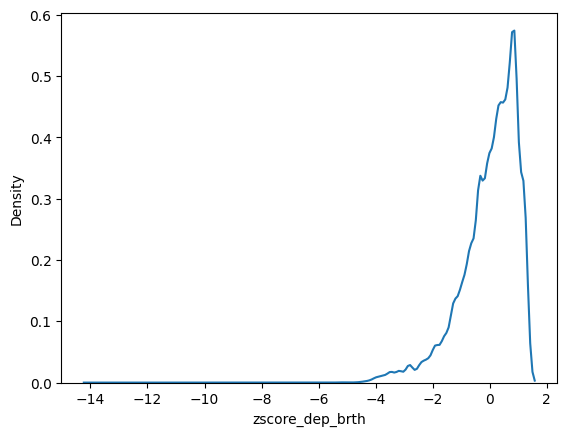

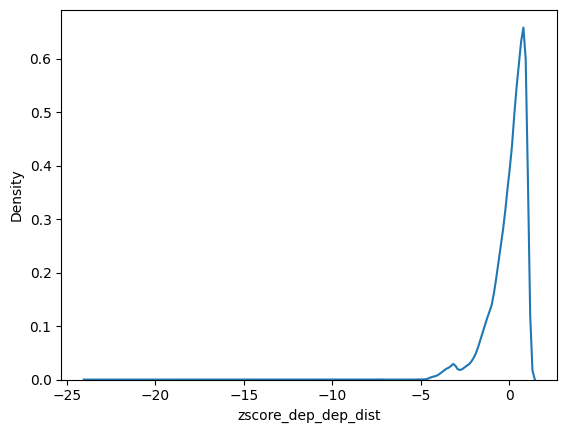

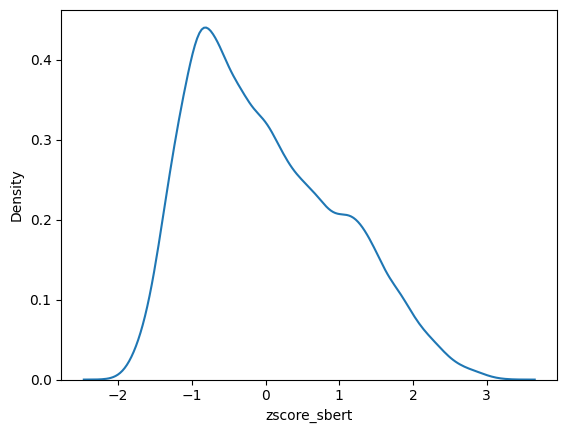

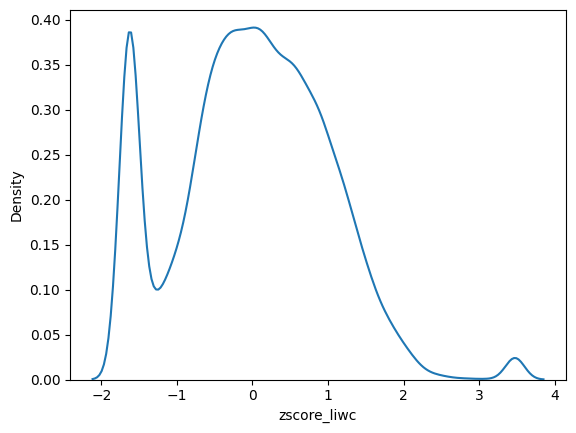

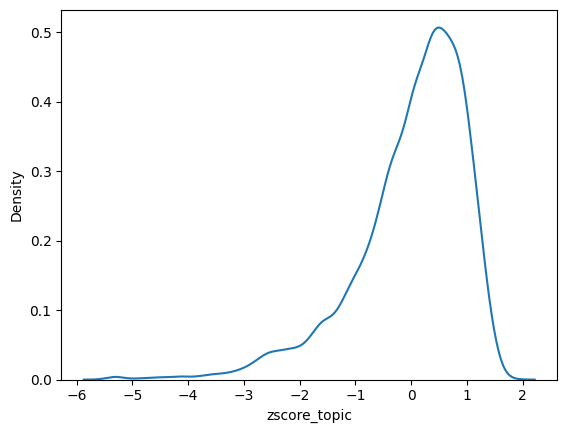

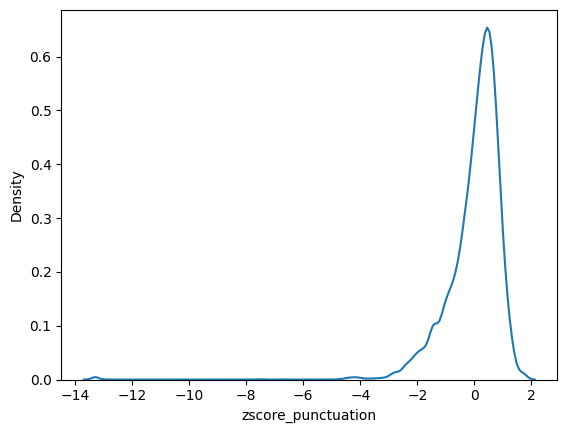

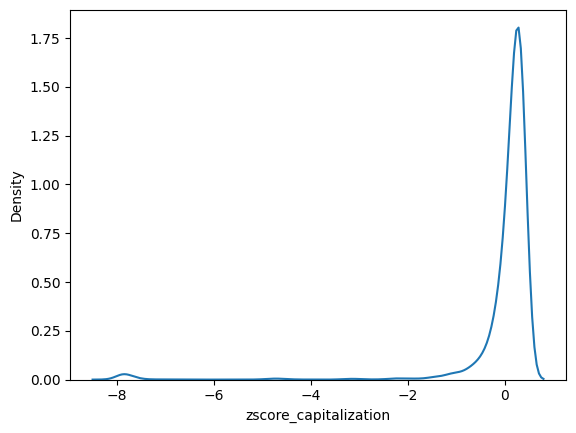

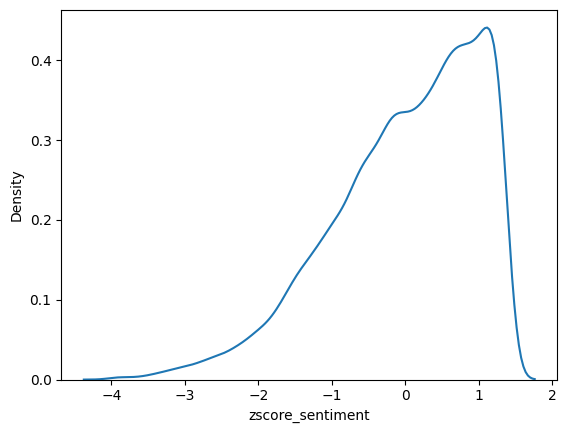

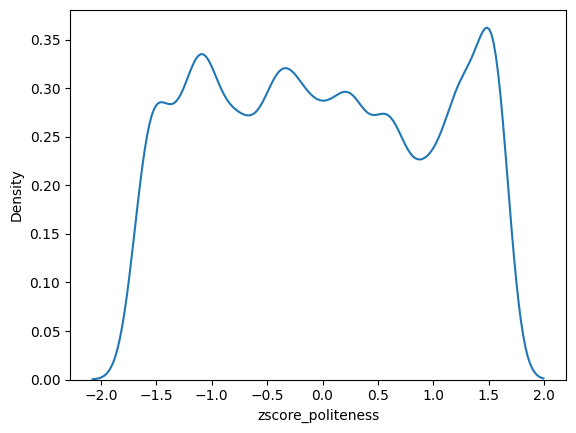

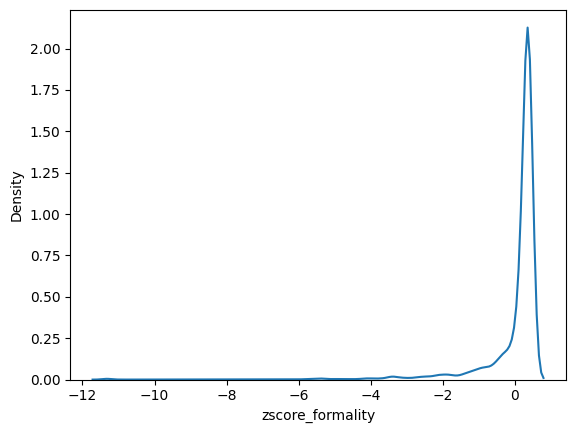

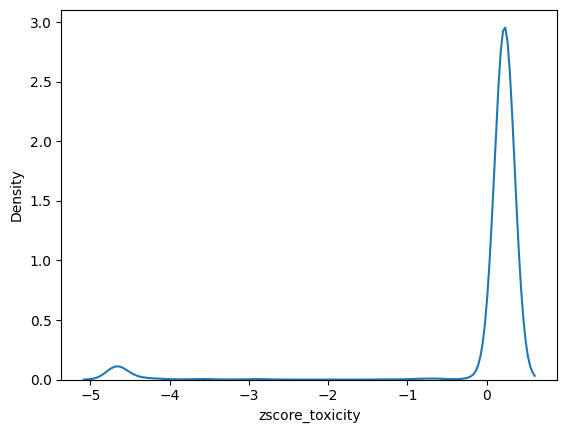

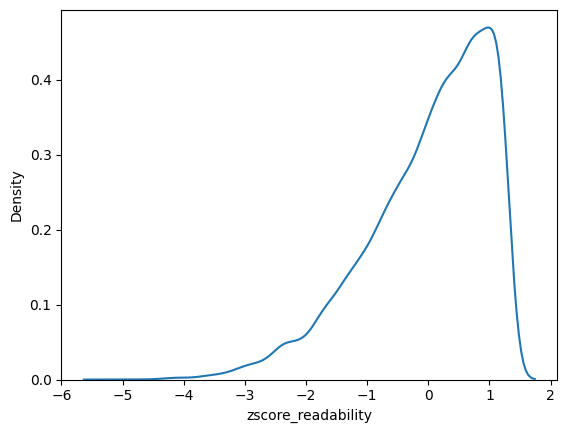

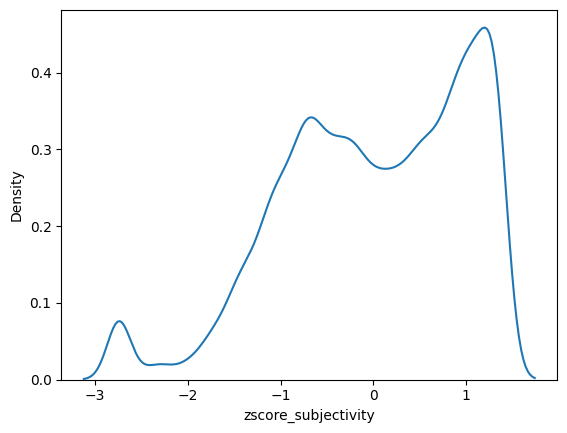

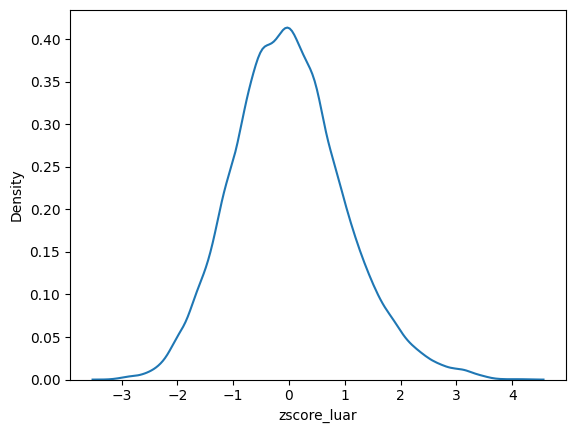

In [21]:
# CREATE NORMALIZED SIMILARITIES BY Z-SCORE
df_zscore = metrics[merge_keys]
for k in all_metrics:
    df_zscore.loc[:,'zscore_'+k] = diff_zscore(metrics['human_'+k], metrics['llm_'+k], all_metrics[k])
    sns.kdeplot(df_zscore['zscore_'+k])
    plt.show()

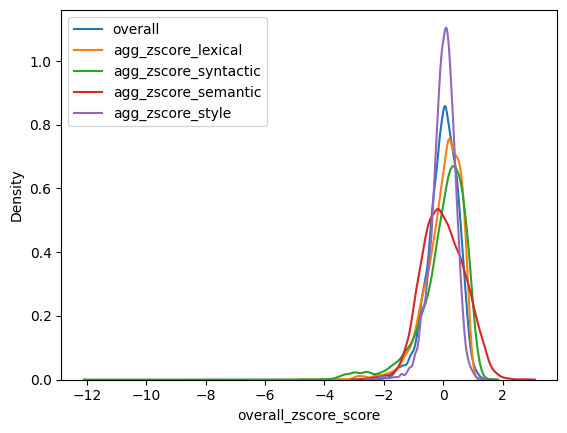

In [22]:
# AGGREGATED SCORES VIA Z-SCORE
df_zscore = aggregate_scores(df_zscore, method = 'zscore')

In [ ]:
df_zscore.to_csv('data/agg_metrics/zscore_normed_metrics.csv', index=None)

pos (63630, 18)
[0.23138853 0.20467897]

sbert (63630, 384)
[0.03283873 0.02992335]

liwc (63630, 70)
[0.44813969 0.0942558 ]

topic (63630, 15)
[0.39602187 0.2630502 ]

punctuation (63630, 33)
[0.67447056 0.13878888]

luar (63630, 512)
[0.08473098 0.0584393 ]



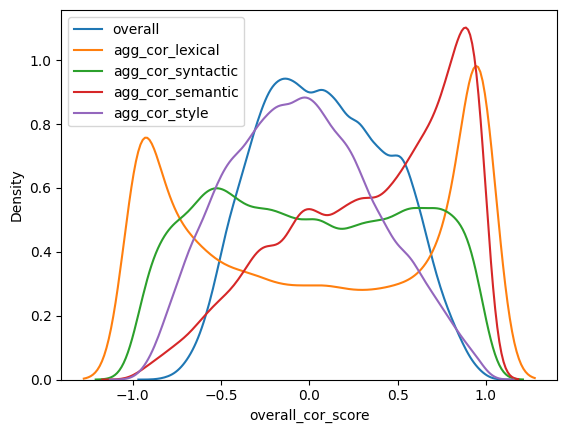

In [23]:
# CREATE NORMALIZED SIMILARITIES BY Z-SCORE
metrics_cor = deepcopy(metrics)
metrics_cor = replace_with_pca(metrics_cor)

#rescale with z-score so differences in scale don't affect the correlation
for k in all_metrics:
    if all_metrics[k] == 'scalar':
        metric = metrics_cor['human_'+k].tolist()
        metric.extend(metrics_cor['llm_'+k].tolist())
        metric = zscore_scale(metric)
        metrics_cor['human_'+k] = metric[:metrics_cor.shape[0]]
        metrics_cor['llm_'+k] = metric[metrics_cor.shape[0]:]
    else:
        human, llm = distribution_scale(metrics_cor['human_'+k], metrics_cor['llm_'+k], scale = zscore_scale)
        metrics_cor['human_'+k] = human 
        metrics_cor['llm_'+k] = llm
        

# AGGREGATED SCORES VIA CORRELATION
df_cor = metrics_cor[merge_keys]
df_cor['agg_cor_lexical'] = metrics_cor.apply(lambda row: dist_row_correlation(row, lexical), axis=1)
df_cor['agg_cor_syntactic'] = metrics_cor.apply(lambda row: dist_row_correlation(row, syntactic), axis=1)
df_cor['agg_cor_semantic'] = metrics_cor.apply(lambda row: dist_row_correlation(row, semantic), axis=1)
df_cor['agg_cor_style'] = metrics_cor.apply(lambda row: dist_row_correlation(row, style), axis=1)
df_cor['overall_cor_score'] = df_cor[[c for c in df_cor.columns 
                                      if c.startswith('agg_cor_')]].apply(lambda x: np.mean(x), axis=1)

sns.kdeplot(df_cor['overall_cor_score'], label='overall')
for k in df_cor.columns:
    if k.startswith('agg_'):
        sns.kdeplot(df_cor[k], label=k)
plt.legend(title= "", loc= "upper left")
plt.show()

In [ ]:
df_cor.to_csv('data/agg_metrics/rowcor_zscore_metrics.csv', index=None)

pos (63630, 18)
[0.23138853 0.20467897]

sbert (63630, 384)
[0.03283872 0.02992334]

liwc (63630, 70)
[0.44813969 0.0942558 ]

topic (63630, 15)
[0.39602187 0.2630502 ]

punctuation (63630, 33)
[0.67447056 0.13878888]

luar (63630, 512)
[0.08473098 0.0584393 ]



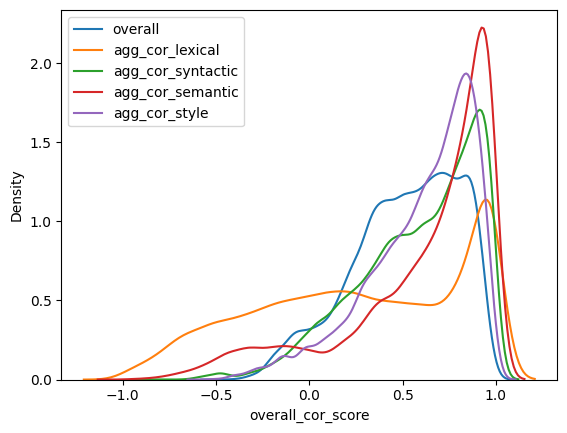

In [24]:
# CREATE NORMALIZED SIMILARITIES BY MIN-MAX
metrics_cor = deepcopy(metrics)
metrics_cor = replace_with_pca(metrics_cor)

#rescale to [0,1] so differences in scale don't affect the correlation
for k in all_metrics:
    if all_metrics[k] == 'scalar':
        metric = metrics_cor['human_'+k].tolist()
        metric.extend(metrics_cor['llm_'+k].tolist())
        metric = min_max_scale(np.array(metric))
        metrics_cor['human_'+k] = metric[:metrics_cor.shape[0]]
        metrics_cor['llm_'+k] = metric[metrics_cor.shape[0]:]
    else:
        human, llm = distribution_scale(metrics_cor['human_'+k], metrics_cor['llm_'+k], scale = min_max_scale)
        metrics_cor['human_'+k] = human 
        metrics_cor['llm_'+k] = llm

# AGGREGATED SCORES VIA CORRELATION
df_cor = metrics_cor[merge_keys]
df_cor['agg_cor_lexical'] = metrics_cor.apply(lambda row: dist_row_correlation(row, lexical), axis=1)
df_cor['agg_cor_syntactic'] = metrics_cor.apply(lambda row: dist_row_correlation(row, syntactic), axis=1)
df_cor['agg_cor_semantic'] = metrics_cor.apply(lambda row: dist_row_correlation(row, semantic), axis=1)
df_cor['agg_cor_style'] = metrics_cor.apply(lambda row: dist_row_correlation(row, style), axis=1)
df_cor['overall_cor_score'] = df_cor[[c for c in df_cor.columns 
                                      if c.startswith('agg_cor_')]].apply(lambda x: np.mean(x), axis=1)

sns.kdeplot(df_cor['overall_cor_score'], label='overall')
for k in df_cor.columns:
    if k.startswith('agg_'):
        sns.kdeplot(df_cor[k], label=k)
plt.legend(title= "", loc= "upper left")
plt.show()

In [ ]:
df_cor.to_csv('data/agg_metrics/rowcor_unit_metrics.csv', index=None)

In [ ]:
# CREATE UNNORMALIZED SIMILARITIES
metrics_cor = deepcopy(metrics)
metrics_cor = replace_with_pca(metrics_cor)

# AGGREGATED SCORES VIA CORRELATION
df_cor = metrics_cor[merge_keys]
df_cor['agg_cor_lexical'] = metrics_cor.apply(lambda row: dist_row_correlation(row, lexical), axis=1)
df_cor['agg_cor_syntactic'] = metrics_cor.apply(lambda row: dist_row_correlation(row, syntactic), axis=1)
df_cor['agg_cor_semantic'] = metrics_cor.apply(lambda row: dist_row_correlation(row, semantic), axis=1)
df_cor['agg_cor_style'] = metrics_cor.apply(lambda row: dist_row_correlation(row, style), axis=1)
df_cor['overall_cor_score'] = df_cor[[c for c in df_cor.columns 
                                      if c.startswith('agg_cor_')]].apply(lambda x: np.mean(x), axis=1)

sns.kdeplot(df_cor['overall_cor_score'], label='overall')
for k in df_cor.columns:
    if k.startswith('agg_'):
        sns.kdeplot(df_cor[k], label=k)
plt.legend(title= "", loc= "upper left")
plt.show()

In [53]:
df_cor.to_csv('data/agg_metrics/rowcor_metrics.csv', index=None)

In [15]:
# from sklearn.cluster import MiniBatchKMeans
# from sklearn.metrics import silhouette_samples, silhouette_score

# k = 'sbert'

# # get embeddings
# X = [x for sim in ['human_','llm_'] for x in metrics[sim+k]]

# from datetime import datetime
# print(datetime.now())
# for n_clusters in range(20,101,10):
#     #make clusters
#     clusterer = MiniBatchKMeans(n_clusters=n_clusters, random_state=0)
#     cluster_labels = clusterer.fit_predict(X)
#     #silhouette score
#     sil = silhouette_score(X, cluster_labels)
#     print(datetime.now(), n_clusters, sil)

2024-08-12 12:00:31.901132
2024-08-12 12:03:12.451830 20 0.034050639635740274



KeyboardInterrupt



In [27]:
# CREATE COLUMN AGGREGATES WITH CORRELATION
model = []
metric = []
cor = []
for mod in set(metrics.model):
    print(mod)
    sub = metrics[metrics.model == mod]
    for k in all_metrics:
        model.append(mod)
        metric.append(k)
        cor.append(col_diff_correlate(sub['human_'+k], sub['llm_'+k], all_metrics[k]))
col_corr = pd.DataFrame({'model': model, 'metric': metric, 'cor': cor})

wildchat_subset_en_2k_prompting_Qwen2-72B-Instruct


In [51]:
col_corr.groupby('category')['cor'].mean()

category
lexical      0.121752
semantic     0.163339
style        0.083133
syntactic    0.076155
Name: cor, dtype: float64

In [54]:
col_corr.to_csv('data/agg_metrics/cor_metrics.csv', index=None)

In [28]:
metric_category = {}
for k in lexical: metric_category[k] = 'lexical'
for k in syntactic: metric_category[k] = 'syntactic'
for k in semantic: metric_category[k] = 'semantic'
for k in style: metric_category[k] = 'style'
col_corr['category'] = col_corr['metric'].replace(metric_category)
Counter(col_corr['category'])

Counter({'style': 9, 'lexical': 4, 'syntactic': 4, 'semantic': 3})

In [29]:
row_zscore = pd.melt(df_zscore.groupby(['model'])[[c for c in df_zscore 
                                                   if c.startswith('zscore_')]].mean().reset_index(),
                    id_vars = ['model'], value_vars = [c for c in df_zscore if c.startswith('zscore_')],
                    var_name = 'metric', value_name = 'zscore')
row_zscore['metric'] = row_zscore['metric'].str.replace('zscore_','')

In [30]:
row_unit = pd.melt(df_unit.groupby(['model'])[[c for c in df_unit if c.startswith('unit_')]].mean().reset_index(),
                    id_vars = ['model'], value_vars = [c for c in df_unit if c.startswith('unit_')],
                    var_name = 'metric', value_name = 'unit')
row_unit['metric'] = row_unit['metric'].str.replace('unit_','')


In [31]:
df_compare = col_corr.\
merge(row_unit, on=['model','metric'], how='left').\
merge(row_zscore, on=['model','metric'], how='left')

In [36]:
df_compare[['cor','unit','zscore']].corr()

,cor,unit,zscore
cor,1.000000,-0.091783,-0.107002
unit,-0.091783,1.000000,0.019401
zscore,-0.107002,0.019401,1.000000


In [43]:
df_compare.sort_values('cor')

,model,metric,cor,category,unit,zscore
15,wildchat_subset_en_2k_prompting_Qwen2-72B-Inst...,formality,-0.007780,style,0.965148,-8.623674e-16
2,wildchat_subset_en_2k_prompting_Qwen2-72B-Inst...,perplexity,0.033664,lexical,0.797327,6.620012e-18
16,wildchat_subset_en_2k_prompting_Qwen2-72B-Inst...,toxicity,0.042004,style,0.953362,-5.327771e-16
19,wildchat_subset_en_2k_prompting_Qwen2-72B-Inst...,luar,0.045287,style,0.736972,-9.428957e-17
6,wildchat_subset_en_2k_prompting_Qwen2-72B-Inst...,dep_brth,0.046831,syntactic,0.815736,5.837264e-17
11,wildchat_subset_en_2k_prompting_Qwen2-72B-Inst...,punctuation,0.062358,style,0.905943,2.498709e-15
12,wildchat_subset_en_2k_prompting_Qwen2-72B-Inst...,capitalization,0.071246,style,0.950844,3.678480e-16
7,wildchat_subset_en_2k_prompting_Qwen2-72B-Inst...,dep_dep_dist,0.072193,syntactic,0.754670,9.402959e-17
9,wildchat_subset_en_2k_prompting_Qwen2-72B-Inst...,liwc,0.075285,semantic,0.466193,3.653459e-16
18,wildchat_subset_en_2k_prompting_Qwen2-72B-Inst...,subjectivity,0.076492,style,0.668299,-1.007035e-16


<Axes: xlabel='unit', ylabel='cor'>

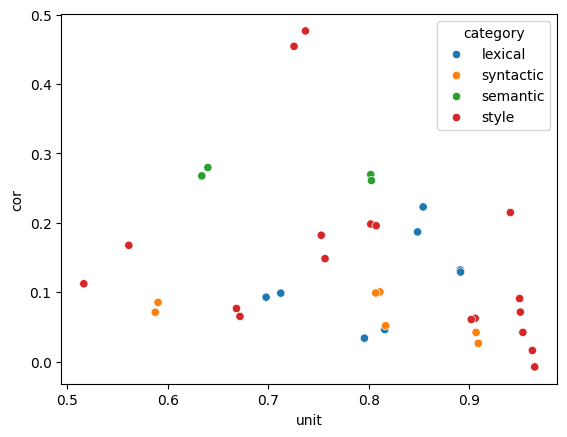

In [38]:
sns.scatterplot(data = df_compare, x = 'unit', y = 'cor', hue='category')

In [47]:
df_cor[[c for c in df_cor.columns if c.startswith('agg_')]].describe()

,agg_cor_lexical,agg_cor_syntactic,agg_cor_semantic,agg_cor_style
count,31622.000000,31815.000000,31815.000000,31815.000000
mean,0.274245,0.583732,0.602742,0.603486
std,0.550758,0.318720,0.406327,0.283340
min,-1.000000,-0.820597,-0.980198,-0.545938
25%,-0.161933,0.377852,0.433611,0.438769
50%,0.302604,0.648189,0.754734,0.672223
75%,0.814161,0.853243,0.908789,0.826502
max,0.999999,0.999950,0.999705,0.998969


<Axes: xlabel='zscore', ylabel='cor'>

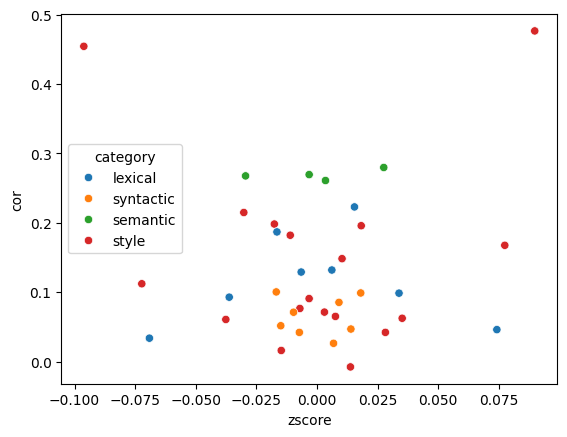

In [39]:
sns.scatterplot(data = df_compare, x = 'zscore', y = 'cor', hue='category')

<Axes: xlabel='zscore', ylabel='unit'>

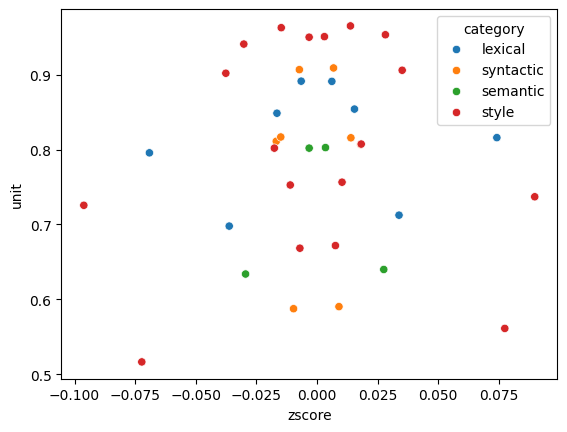

In [40]:
sns.scatterplot(data = df_compare, x = 'zscore', y = 'unit', hue='category')

In [37]:
row_cor = pd.melt(df_cor.groupby(['model'])[[c for c in df_cor 
                                             if c.startswith('agg_')]].mean().reset_index(),
                    id_vars = ['model'], value_vars = [c for c in df_cor if c.startswith('agg_')],
                    var_name = 'category', value_name = 'row_cor')
row_cor['category'] = row_cor['category'].str.replace('agg_cor_','')

In [38]:
df_cat_compare = df_compare.drop('metric', axis=1).groupby(['model','category']).mean().reset_index().\
merge(row_cor, on=['model','category'], how='left')

In [44]:
df_cat_compare

,model,category,cor,unit,zscore,row_cor
0,wildchat_subset_en_2k_prompting_Qwen2-72B-Inst...,lexical,0.121752,0.824246,6.181651e-17,0.274245
1,wildchat_subset_en_2k_prompting_Qwen2-72B-Inst...,semantic,0.163339,0.636002,-9.435587e-17,0.602742
2,wildchat_subset_en_2k_prompting_Qwen2-72B-Inst...,style,0.083133,0.806152,1.160774e-16,0.603486
3,wildchat_subset_en_2k_prompting_Qwen2-72B-Inst...,syntactic,0.076155,0.742938,2.089978e-17,0.583732


In [39]:
df_cat_compare.drop(['model','category'], axis=1).corr()

,cor,unit,zscore,row_cor
cor,1.000000,-0.632847,-0.766175,-0.146781
unit,-0.632847,1.000000,0.942950,-0.568249
zscore,-0.766175,0.942950,1.000000,-0.267418
row_cor,-0.146781,-0.568249,-0.267418,1.000000


<Axes: xlabel='zscore', ylabel='cor'>

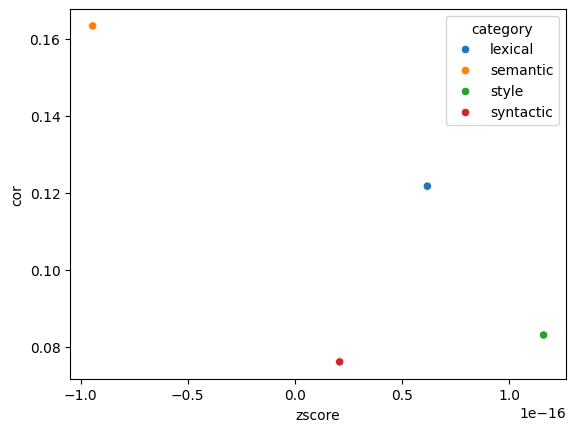

In [40]:
sns.scatterplot(data = df_cat_compare, x = 'zscore', y = 'cor', hue='category')

<Axes: xlabel='unit', ylabel='cor'>

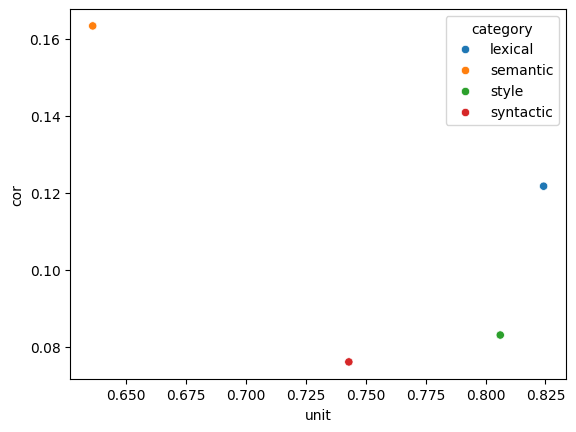

In [41]:
sns.scatterplot(data = df_cat_compare, x = 'unit', y = 'cor', hue='category')

<Axes: xlabel='row_cor', ylabel='cor'>

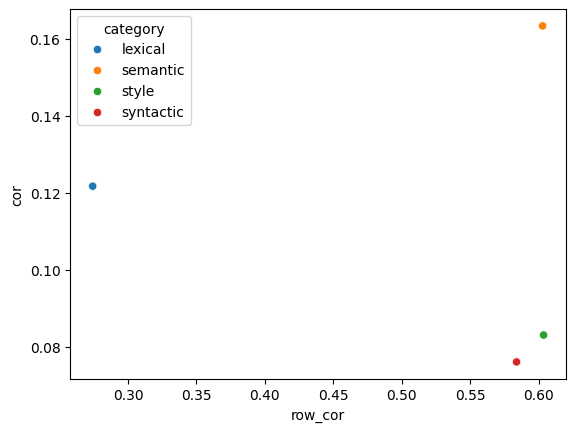

In [42]:
sns.scatterplot(data = df_cat_compare, x = 'row_cor', y = 'cor', hue='category')

In [53]:
df_cat_compare

,model,category,cor,unit,zscore,row_cor
0,wildchat_subset_en_2k_prompting_Qwen2-72B-Inst...,lexical,0.121752,0.824246,6.181651e-17,0.748217
1,wildchat_subset_en_2k_prompting_Qwen2-72B-Inst...,semantic,0.208154,0.636002,-9.435587e-17,0.352913
2,wildchat_subset_en_2k_prompting_Qwen2-72B-Inst...,style,0.131054,0.806152,1.160774e-16,-0.100328
3,wildchat_subset_en_2k_prompting_Qwen2-72B-Inst...,syntactic,0.064671,0.781522,-4.576900e-17,0.949158


In [55]:
df_compare.sort_values('cor')

,model,metric,cor,category,unit,zscore
15,wildchat_subset_en_2k_prompting_Qwen2-72B-Inst...,formality,-0.007780,style,0.965148,-8.623674e-16
7,wildchat_subset_en_2k_prompting_Qwen2-72B-Inst...,dep_avg_brth,0.026258,syntactic,0.909007,-1.726455e-16
2,wildchat_subset_en_2k_prompting_Qwen2-72B-Inst...,perplexity,0.033664,lexical,0.797327,6.620012e-18
16,wildchat_subset_en_2k_prompting_Qwen2-72B-Inst...,toxicity,0.042004,style,0.953362,-5.327771e-16
6,wildchat_subset_en_2k_prompting_Qwen2-72B-Inst...,dep_brth,0.046831,syntactic,0.815736,5.837264e-17
11,wildchat_subset_en_2k_prompting_Qwen2-72B-Inst...,punctuation,0.062358,style,0.905943,2.498709e-15
12,wildchat_subset_en_2k_prompting_Qwen2-72B-Inst...,capitalization,0.071246,style,0.950844,3.678480e-16
9,wildchat_subset_en_2k_prompting_Qwen2-72B-Inst...,liwc,0.075285,semantic,0.466193,3.653459e-16
18,wildchat_subset_en_2k_prompting_Qwen2-72B-Inst...,subjectivity,0.076492,style,0.668299,-1.007035e-16
4,wildchat_subset_en_2k_prompting_Qwen2-72B-Inst...,pos,0.085266,syntactic,0.590267,-1.280691e-16


In [ ]:
metrics.to_json('data/wildchat_subset_en_2k_prompting_all_normalized_metrics.jsonl', orient='records', lines=True)

In [135]:
1

1

In [184]:
ann = pd.read_csv('/home/akananth/Misc/human-llm-similarity/src/annotation/annotation_output/annotated_instances.tsv',
                  sep='\t')

In [185]:
ann.shape

(1272, 8)

In [186]:
import json
assign = json.load(open('/home/akananth/Misc/human-llm-similarity/src/annotation/annotation_output/task_assignment.json','r'))

In [187]:
Counter([v[0] if len(v)==1 else '' 
         for k,v in assign['assigned'].items() if k not in ann.instance_id.tolist()])

Counter({'': 1})

In [188]:
all_ids = set(metrics['hashed_ip']+metrics['conversation_hash'])

In [189]:
len(all_ids)

731

In [190]:
Counter([x in ann['instance_id'][~ann['ResponseText:::text_box'].isna()].tolist() for x in all_ids])

Counter({False: 441, True: 290})